# Predictive Benchmark – Hotel Bookings

Notebook for dataset ingestion, schema checks, preprocessing design, and modelling tasks.
All tasks follow: Plan → Risks → Implementation → Verification → Revised final answer.

---
## Task 1: Dataset ingestion, schema checks, and preprocessing design

**Deliverables:** Schema understanding, variable interpretation (documentation vs data), missing values, data quality issues, leakage/methodological risk flags, preprocessing plan, verification.

### 1. Plan

1. **Documentation review** – Read `dataset_description.txt` to extract variable meanings, temporal availability (day prior to arrival), leakage considerations, and preprocessing hints (e.g. NULL = "not applicable" for Agent/Company).
2. **Dataset structure** – Load `hotel_bookings.csv`, inspect shape, dtypes, column names; align with documentation (CSV uses snake_case).
3. **Missing values** – Count nulls per column; treat Agent/Company/country "NULL" as documented (not applicable where stated); distinguish from true missing.
4. **Data quality** – Check impossible values (e.g. adults=0, negative ADR), inconsistent categories, duplicate rows, suspicious distributions.
5. **Leakage and risk** – Flag variables that are post-outcome or otherwise risky (e.g. ReservationStatus, ReservationStatusDate, ADR for canceled).
6. **Preprocessing plan** – Propose handling for missingness, quality issues, leakage, and feature types; no modelling.
7. **Verification** – Sanity-check counts and interpretations against documentation; state uncertainties.

### 2. Risks

- **Data leakage** – Using ReservationStatus/ReservationStatusDate or ADR (for canceled) as features would leak outcome information.
- **Invalid evaluation** – Not excluding or clearly handling leakage variables would inflate metrics.
- **Reproducibility** – Random sampling or non-fixed operations must use a fixed seed; document any filtering.
- **Misleading interpretation** – Treating Agent/Company "NULL" as missing would distort analysis; doc says "not applicable".
- **Data quality** – Zero adults, negative ADR, or inconsistent categories could bias preprocessing and later models.
- **Unsupported assumptions** – Assuming all variables are known at booking time; doc states some (e.g. nationality) may be known only at check-in.

In [1]:
import os
import numpy as np
import pandas as pd

# Reproducibility for any stochastic operations later in the pipeline
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Read documentation first (dataset_description.txt)
project_root = os.path.dirname(os.path.abspath("hotel_bookings.csv"))
doc_path = os.path.join(project_root, "dataset_description.txt")
doc_available = os.path.exists(doc_path)
doc_text = ""
if doc_available:
    with open(doc_path, "r", encoding="utf-8", errors="replace") as f:
        doc_text = f.read()
    print(f"Read documentation: {doc_path} ({len(doc_text)} chars)")
else:
    print(f"WARNING: Documentation not found at {doc_path}")

# Load the bookings dataset
csv_path = os.path.join(project_root, "hotel_bookings.csv")
df = pd.read_csv(csv_path)
print("\nLoaded `hotel_bookings.csv`.")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Basic structural overview
display(df.head())
print("\nData types:\n")
print(df.dtypes)


Read documentation: c:\Users\user\Downloads\PredictiveGroupProject\dataset_description.txt (20687 chars)

Loaded `hotel_bookings.csv`.
Shape: 119,390 rows x 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



Data types:

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent               

In [2]:
# df already loaded above. Schema: dtypes and non-null counts.
print("Schema: dtypes and non-null counts")
df.info()

Schema: dtypes and non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-

In [3]:
# Schema summary: combine technical schema with high-level roles

schema = (
    df.dtypes.rename("dtype")
    .to_frame()
    .reset_index()
    .rename(columns={"index": "column"})
)

# High-level, documentation-guided roles and interpretations.
# Where documentation is missing, these are clearly marked as inferred.

role_map = {
    "hotel": ("categorical", "Hotel identifier (e.g. Resort vs City)", "feature", "inferred_from_data"),
    "is_canceled": ("binary", "Whether the booking was eventually canceled", "target", "inferred_from_common_usage"),
    "lead_time": ("numeric", "Days between booking date and arrival date", "feature", "inferred_from_common_usage"),
    "arrival_date_year": ("numeric", "Year of the arrival date", "feature", "inferred_from_data"),
    "arrival_date_month": ("categorical", "Month of the arrival date", "feature", "inferred_from_data"),
    "arrival_date_week_number": ("numeric", "Week number of arrival date", "feature", "inferred_from_data"),
    "arrival_date_day_of_month": ("numeric", "Day of month of arrival date", "feature", "inferred_from_data"),
    "stays_in_weekend_nights": ("numeric", "Number of weekend nights (Sat/Sun) stayed or booked", "feature", "inferred_from_data"),
    "stays_in_week_nights": ("numeric", "Number of weekday nights stayed or booked", "feature", "inferred_from_data"),
    "adults": ("numeric", "Number of adults in the booking", "feature", "inferred_from_data"),
    "children": ("numeric", "Number of children in the booking", "feature", "inferred_from_data"),
    "babies": ("numeric", "Number of babies in the booking", "feature", "inferred_from_data"),
    "meal": ("categorical", "Type of meal plan booked", "feature", "inferred_from_data"),
    "country": ("categorical", "Country of origin of the booking", "feature", "inferred_from_data"),
    "market_segment": ("categorical", "Market segment (e.g. Direct, Online TA)", "feature", "inferred_from_data"),
    "distribution_channel": ("categorical", "Booking distribution channel", "feature", "inferred_from_data"),
    "is_repeated_guest": ("binary", "Whether the guest has stayed before", "feature", "inferred_from_data"),
    "previous_cancellations": ("numeric", "Number of previous cancellations by this customer", "feature", "inferred_from_data"),
    "previous_bookings_not_canceled": ("numeric", "Number of previous successful bookings", "feature", "inferred_from_data"),
    "reserved_room_type": ("categorical", "Code for the room type reserved", "feature", "inferred_from_data"),
    "assigned_room_type": ("categorical", "Code for the room type assigned", "feature", "inferred_from_data"),
    "booking_changes": ("numeric", "Number of changes/amendments to the booking", "feature", "inferred_from_data"),
    "deposit_type": ("categorical", "Deposit type (No deposit / Non-refund / Refundable)", "feature", "inferred_from_data"),
    "agent": ("categorical", "Travel agent identifier (if used)", "feature", "inferred_from_data"),
    "company": ("categorical", "Company identifier for corporate bookings", "feature", "inferred_from_data"),
    "days_in_waiting_list": ("numeric", "Days booking spent on the waiting list", "feature", "inferred_from_data"),
    "customer_type": ("categorical", "Customer type (Transient, Contract, etc.)", "feature", "inferred_from_data"),
    "adr": ("numeric", "Average Daily Rate (monetary value)", "feature", "inferred_from_data"),
    "required_car_parking_spaces": ("numeric", "Number of car parking spaces required", "feature", "inferred_from_data"),
    "total_of_special_requests": ("numeric", "Total number of special requests", "feature", "inferred_from_data"),
    "reservation_status": ("categorical", "Final reservation status (Check-Out, Canceled, No-Show)", "leakage_risk", "inferred_from_common_usage"),
    "reservation_status_date": ("datetime-like", "Date of the last reservation status update", "leakage_risk", "inferred_from_common_usage"),
}

role_df = pd.DataFrame.from_dict(
    role_map, orient="index", columns=["semantic_type", "description", "role", "evidence_source"]
).reset_index().rename(columns={"index": "column"})

schema = schema.merge(role_df, on="column", how="left")

schema.sort_values("column", inplace=True)

print("Schema summary (technical + semantic):")
display(schema)


Schema summary (technical + semantic):


,column,dtype,semantic_type,description,role,evidence_source
27,adr,float64,numeric,Average Daily Rate (monetary value),feature,inferred_from_data
9,adults,int64,numeric,Number of adults in the booking,feature,inferred_from_data
23,agent,float64,categorical,Travel agent identifier (if used),feature,inferred_from_data
6,arrival_date_day_of_month,int64,numeric,Day of month of arrival date,feature,inferred_from_data
4,arrival_date_month,object,categorical,Month of the arrival date,feature,inferred_from_data
5,arrival_date_week_number,int64,numeric,Week number of arrival date,feature,inferred_from_data
3,arrival_date_year,int64,numeric,Year of the arrival date,feature,inferred_from_data
20,assigned_room_type,object,categorical,Code for the room type assigned,feature,inferred_from_data
11,babies,int64,numeric,Number of babies in the booking,feature,inferred_from_data
21,booking_changes,int64,numeric,Number of changes/amendments to the booking,feature,inferred_from_data


In [4]:
# Missing values: pandas nulls
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
missing = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
missing = missing[missing["null_count"] > 0].sort_values("null_count", ascending=False)
print("Columns with pandas null (NaN):")
print(missing)
print("\nColumns with no pandas null:", (null_counts == 0).sum())

Columns with pandas null (NaN):
          null_count  null_pct
company       112593     94.31
agent          16340     13.69
country          488      0.41
children           4      0.00

Columns with no pandas null: 28


In [5]:
# "NULL" as string (documentation: Agent/Company NULL = not applicable, not missing)
object_cols = df.select_dtypes(include=["object"]).columns
for c in object_cols:
    n_null_str = (df[c].astype(str).str.upper() == "NULL").sum()
    if n_null_str > 0:
        print(f"{c}: string 'NULL' count = {n_null_str} ({100*n_null_str/len(df):.2f}%)")

In [6]:
# Missing values: column-wise and row-wise assessment

missing_per_column = df.isna().sum().to_frame(name="n_missing")
missing_per_column["missing_rate"] = missing_per_column["n_missing"] / len(df)
missing_per_column.sort_values("missing_rate", ascending=False, inplace=True)

print("Column-wise missingness (sorted by missing_rate):")
display(missing_per_column)

# Row-wise missingness distribution
row_missing_counts = df.isna().sum(axis=1)
row_missing_summary = row_missing_counts.value_counts().sort_index().to_frame(name="n_rows")

print("\nRow-wise missingness distribution (number of missing cells per row):")
display(row_missing_summary)

# Inspect missingness patterns for selected key variables
key_vars = [
    "children",
    "babies",
    "agent",
    "company",
    "country",
]

existing_key_vars = [c for c in key_vars if c in df.columns]

if existing_key_vars:
    print("\nMissingness rates for selected key variables:")
    display(df[existing_key_vars].isna().mean().to_frame(name="missing_rate"))

# Example: explore how missingness in `agent` and `company` relates to market segment
for col in ["agent", "company"]:
    if col in df.columns and "market_segment" in df.columns:
        temp = (
            df.assign(**{f"{col}_is_missing": df[col].isna()})
            .groupby(["market_segment", f"{col}_is_missing"])
            .size()
            .unstack(fill_value=0)
        )
        print(f"\nMissingness of `{col}` by market_segment:")
        display(temp)


Column-wise missingness (sorted by missing_rate):


,n_missing,missing_rate
company,112593,0.943069
agent,16340,0.136862
country,488,0.004087
children,4,0.000034
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000



Row-wise missingness distribution (number of missing cells per row):


,n_rows
0,217
1,109083
2,9928
3,162



Missingness rates for selected key variables:


,missing_rate
children,0.000034
babies,0.000000
agent,0.136862
company,0.943069
country,0.004087



Missingness of `agent` by market_segment:


agent_is_missing,False,True
market_segment,,
Aviation,25,212
Complementary,103,640
Corporate,701,4594
Direct,6599,6007
Groups,15663,4148
Offline TA/TO,23830,389
Online TA,56129,348
Undefined,0,2



Missingness of `company` by market_segment:


company_is_missing,False,True
market_segment,,
Aviation,212,25
Complementary,313,430
Corporate,4471,824
Direct,208,12398
Groups,1391,18420
Offline TA/TO,106,24113
Online TA,96,56381
Undefined,0,2


In [7]:
# Duplicate rows (exact duplicates)
n_dup = df.duplicated().sum()
print("Exact duplicate rows:", n_dup)
if n_dup > 0:
    print("Example duplicated rows (first 2):")
    print(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(4))

Exact duplicate rows: 31994
Example duplicated rows (first 2):
            hotel  is_canceled  lead_time  arrival_date_year  \
40772  City Hotel            0          0               2015   
40802  City Hotel            0          0               2015   
40821  City Hotel            0          0               2015   
40838  City Hotel            0          0               2015   

      arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
40772             August                        32                          7   
40802             August                        32                          7   
40821             August                        32                          8   
40838             August                        32                          8   

       stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
40772                        0                     2       2  ...   
40802                        0                     2       2  ...   
408

In [8]:
# Data quality checks: impossible values, inconsistent categories, duplicates, distributions

issues = {}

# 1. Basic numeric sanity checks
numeric_cols = df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    issues[col] = {"min": col_min, "max": col_max}

numeric_ranges = pd.DataFrame(issues).T
print("Numeric value ranges (min/max):")
display(numeric_ranges)

# Domain-specific plausibility checks (based on typical hotel booking data)
plausibility_flags = {}

if "adults" in df.columns:
    plausibility_flags["adults_non_positive"] = (df["adults"] <= 0).sum()
if "children" in df.columns:
    plausibility_flags["children_negative"] = (df["children"] < 0).sum()
if "babies" in df.columns:
    plausibility_flags["babies_negative"] = (df["babies"] < 0).sum()
if "stays_in_weekend_nights" in df.columns:
    plausibility_flags["stays_in_weekend_nights_negative"] = (df["stays_in_weekend_nights"] < 0).sum()
if "stays_in_week_nights" in df.columns:
    plausibility_flags["stays_in_week_nights_negative"] = (df["stays_in_week_nights"] < 0).sum()
if "adr" in df.columns:
    plausibility_flags["adr_negative"] = (df["adr"] < 0).sum()

print("\nPlausibility flag counts (selected numeric anomalies):")
print(plausibility_flags)

# 2. Category consistency for selected fields
cat_cols = [
    c for c in [
        "hotel",
        "meal",
        "market_segment",
        "distribution_channel",
        "deposit_type",
        "customer_type",
        "reservation_status",
    ]
    if c in df.columns
]

for col in cat_cols:
    print(f"\nUnique categories for `{col}` (top 20):")
    display(df[col].value_counts(dropna=False).head(20))

# 3. Check for duplicated rows
n_duplicates = df.duplicated().sum()
print(f"\nNumber of fully duplicated rows: {n_duplicates}")


Numeric value ranges (min/max):


,min,max
is_canceled,0.00,1.0
lead_time,0.00,737.0
arrival_date_year,2015.00,2017.0
arrival_date_week_number,1.00,53.0
arrival_date_day_of_month,1.00,31.0
stays_in_weekend_nights,0.00,19.0
stays_in_week_nights,0.00,50.0
adults,0.00,55.0
children,0.00,10.0
babies,0.00,10.0



Plausibility flag counts (selected numeric anomalies):
{'adults_non_positive': np.int64(403), 'children_negative': np.int64(0), 'babies_negative': np.int64(0), 'stays_in_weekend_nights_negative': np.int64(0), 'stays_in_week_nights_negative': np.int64(0), 'adr_negative': np.int64(1)}

Unique categories for `hotel` (top 20):


hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


Unique categories for `meal` (top 20):


...


Unique categories for `customer_type` (top 20):


customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


Unique categories for `reservation_status` (top 20):


reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64


Number of fully duplicated rows: 31994


In [9]:
# Stays vs adults/children/babies: total guests should be consistent with stays (sanity)
# Doc: StaysInWeekendNights + StaysInWeekNights = total nights; no explicit constraint on guest count vs nights
total_guests = df["adults"] + df["children"].fillna(0) + df["babies"]
print("Rows with total_guests == 0:", (total_guests == 0).sum())
print("lead_time < 0:", (df["lead_time"] < 0).sum())
print("arrival_date_year range:", df["arrival_date_year"].min(), "-", df["arrival_date_year"].max())

Rows with total_guests == 0: 180
lead_time < 0: 0
arrival_date_year range: 2015 - 2017


## Verification for Task 1

- The dataset loads successfully from `hotel_bookings.csv`, and the structural summary (shape, dtypes, head) is printed.
- A combined schema table reports the technical type, an interpreted semantic description, the tentative role (feature/target/leakage_risk), and whether each interpretation is derived from domain conventions or inferred from data and variable names.
- Missingness is quantified per column and per row, with additional breakdowns of missingness for key variables (`agent`, `company`, `country`, children/babies) across market segments where applicable.
- Data quality checks report numeric ranges, simple plausibility flags (e.g. non-positive adults, negative nights or rates), category enumerations for several key categorical variables, and the count of fully duplicated rows.
- No modelling or target leakage has been introduced in the code; all analysis is descriptive and oriented toward preprocessing design.

## Revised final answer for Task 1

### 1. Dataset schema understanding

- The dataset `hotel_bookings.csv` contains hotel booking records with columns that include hotel identifier (`hotel`), booking and arrival timing (`lead_time`, `arrival_date_year`, `arrival_date_month`, `arrival_date_week_number`, `arrival_date_day_of_month`), stay characteristics (`stays_in_weekend_nights`, `stays_in_week_nights`), party composition (`adults`, `children`, `babies`), booking context (`meal`, `country`, `market_segment`, `distribution_channel`, `deposit_type`, `customer_type`, `agent`, `company`), booking history (`is_repeated_guest`, `previous_cancellations`, `previous_bookings_not_canceled`), room allocation (`reserved_room_type`, `assigned_room_type`), booking dynamics (`booking_changes`, `days_in_waiting_list`, `total_of_special_requests`), price (`adr`), and outcome-related fields (`is_canceled`, `reservation_status`, `reservation_status_date`).
- **Documentation-derived vs inferred**: Because `dataset_description.pdf` is not available in the current environment, variable meanings are inferred from standard usage in hotel booking datasets and from observed names/patterns. These inferences are flagged in the schema table via the `evidence_source` column (e.g. `inferred_from_common_usage`, `inferred_from_data`).
- **Target definition (inferred)**: `is_canceled` is treated as the natural binary target indicating whether a booking was ultimately canceled.

### 2. Variable interpretation based on documentation vs data

- **Derived from documentation**: Exact coding of categories (meal plans, market segments, customer types), temporal scope (day prior to arrival), and NULL semantics come from `dataset_description.txt`. We use these where stated and otherwise infer from variable names and data patterns.
- **Inferred from data patterns and common domain knowledge**:
  - Timing variables (`lead_time`, arrival date components) describe pre-arrival information available at booking time.
  - Stay composition and length variables are pre-stay characteristics determined at booking.
  - `market_segment`, `distribution_channel`, `agent`, and `company` describe how the booking was sourced and are likely known at or before booking.
  - `reservation_status` and `reservation_status_date` encode the final state and timing of the booking outcome and are therefore post-outcome variables.
  - `adr` (Average Daily Rate) represents the monetary value per occupied room night and is typically determined before or at booking but can also encode discounts and modifications.

### 3. Missing value assessment

- Column-wise missingness is computed for all variables, with rates sorted descending; in this dataset, missingness is expected to be concentrated in optional fields like `children`, `babies`, `agent`, `company`, and sometimes `country`.
- Row-wise missingness shows how many cells are missing per record; this helps distinguish a few partially missing fields from structurally under-specified bookings.
- Cross-tabulations of missingness for `agent` and `company` against `market_segment` highlight that many market segments (e.g. Direct, Corporate, Online TA) have structurally different patterns: some segments rarely populate `agent`/`company`, so their missingness is likely **structural** rather than random.

### 4. Data quality issues detected (based on the checks)

- **Numeric plausibility**:
  - Checks for non-positive `adults`, negative `children`, `babies`, nights, or `adr` values flag any implausible entries (e.g. bookings with zero adults or negative rates). These should be very rare; if counts are non-zero, they warrant either recoding or exclusion.
  - Min/max ranges for stay lengths and `adr` help spot outliers (e.g. extremely long stays or extremely high daily rates) that may reflect data entry errors or unusual but real cases.
- **Categorical consistency**:
  - Value counts for `hotel`, `meal`, `market_segment`, `distribution_channel`, `deposit_type`, `customer_type`, and `reservation_status` show a small, finite set of categories, as expected. String categories like `"NULL"` (seen in the raw CSV for `agent`/`company`) indicate that some missing values are encoded as literal strings rather than true NaN.
- **Duplicates**:
  - The number of fully duplicated rows is reported. Non-zero duplicates may either reflect exact repeated bookings in the source system or data duplication in preprocessing; they should be reviewed before modelling.

### 5. Leakage and methodological risk flags

- **High leakage risk variables (post-outcome or outcome-equivalent)**:
  - `reservation_status` (e.g. `Check-Out`, `Canceled`, `No-Show`) effectively encodes the outcome and is strongly correlated with `is_canceled`; using it as a feature would constitute label leakage.
  - `reservation_status_date` is typically the date when the final status was set, which occurs on or after the outcome; including it would leak future information.
- **Potentially problematic variables**:
  - `adr` and `booking_changes` may reflect information that is updated after the initial booking; depending on the prediction time (at-booking vs later), they could partially encode post-decision information.
  - `days_in_waiting_list` may depend on subsequent events after the initial booking request and could leak future capacity decisions.
  - `assigned_room_type` can differ from `reserved_room_type` and may be updated close to check-in; using it when predicting at booking time could introduce leakage, whereas `reserved_room_type` is safer.
- **Bias and stability risks**:
  - `country`, `agent`, and `company` may produce spurious or unstable patterns driven by specific partners or geographies; heavy reliance on these fields could reduce generalisability.

### 6. Recommended preprocessing strategy (no modelling yet)

- **Missing data handling**:
  - Convert sentinel strings like `"NULL"` in `agent` and `company` to proper NaN, then treat these variables as high-cardinality categorical features. Consider grouping rare categories into an `"Other"` bucket if used later.
  - For `children` and `babies`, treat zeros as valid counts but ensure there are no negative values; if isolated negative or impossible values exist, either recode them to NaN or drop the affected rows after confirming they are data errors.
  - For `country`, consider keeping missing as a separate `Unknown` category if the rate is low to moderate; if missingness is strongly segment-specific, document it as structural.
- **Feature selection around leakage**:
  - Exclude `reservation_status` and `reservation_status_date` from any feature set used to predict cancellations at booking time.
  - Treat `assigned_room_type`, `days_in_waiting_list`, and `booking_changes` with caution; include them only if the intended prediction time logically occurs after those fields are observed, and clearly document that choice.
- **Encoding and scaling**:
  - Plan to use appropriate encodings for categorical variables (e.g. one-hot or target encoding) and scaling for continuous features such as `lead_time`, `adr`, and stay length variables.
- **Data cleaning**:
  - Remove or cap extreme outliers in `adr` and extremely long stays if they are confirmed to be data entry errors rather than genuine bookings.
  - Deduplicate exact duplicate rows unless multiple identical bookings are known to be plausible events.

### 7. Verification and remaining uncertainties

- The analysis code focuses solely on descriptive statistics and diagnostics; no models are fit, and no data splits are created, so there is no evaluation leakage at this stage.
- Remaining uncertainties: exact timing of some variables (e.g. country may be known only at check-in per doc), duplicate-row semantics, and any provider-side preprocessing. Documentation (`dataset_description.txt`) was used for variable meanings and leakage guidance.
- To resolve these uncertainties in a real benchmark, the next step would be to cross-check the inferred interpretations and preprocessing plan against the official documentation and, if necessary, revise the status of variables currently flagged as potential leakage or bias sources.


In [10]:
# Confirm: is_canceled vs reservation_status
print("Cross-tab: is_canceled vs reservation_status")
print(pd.crosstab(df["is_canceled"], df["reservation_status"], margins=True))

Cross-tab: is_canceled vs reservation_status
reservation_status  Canceled  Check-Out  No-Show     All
is_canceled                                             
0                          0      75166        0   75166
1                      43017          0     1207   44224
All                    43017      75166     1207  119390


### 5. Preprocessing plan (recommended)

1. **Exclude from features (leakage / target)**  
   - Drop or do not use: `reservation_status`, `reservation_status_date`, `is_canceled` (target only).

2. **ADR**  
   - For cancellation prediction: exclude ADR, or use only for non-canceled rows in analyses that are not predicting cancellation. If retained for other tasks, cap or treat ADR=0 / negative as a separate category and document.

3. **Missing / NULL**  
   - `children`: few nulls; impute 0 (documented as count) or drop rows.  
   - `country`: doc says may be unknown until check-in; treat as "unknown" category or separate flag; do not treat as missing at random.  
   - `agent` / `company`: doc says "NULL" = not applicable; keep as category (e.g. "None" or "Direct"), do not impute.

4. **Data quality**  
   - **Adults = 0**: drop rows for modelling (no guest), or flag and treat separately; document.  
   - **ADR < 0**: set to 0 or treat as missing for that row if used.  
   - **Duplicates**: drop exact duplicates after documenting count; consider keeping one representative row per booking if duplicates are logical (e.g. same booking, multiple records).

5. **Categorical**  
   - Encode `meal`, `country`, `market_segment`, `distribution_channel`, `deposit_type`, `customer_type`, `reserved_room_type`, `assigned_room_type` (if retained), `hotel`; keep agent/company as categorical (including NULL).

6. **Reproducibility**  
   - Fix random seed for any sampling or stochastic steps; document filter logic and ordering so notebook is executable top-to-bottom.

In [11]:
# Summary: missing value assessment (for report)
print("Missing value assessment:")
print("1. Pandas NaN: company, agent, country, children (see null_counts above).")
print("2. Doc: Agent/Company 'NULL' = not applicable (booking not from agency/company).")
print("3. True missing: children (small), country (doc: may be unknown until check-in).")
df_na = df.isnull().sum()
for col in ["children", "country", "agent", "company"]:
    if col in df.columns:
        print(f"  {col}: {df_na[col]} nulls")

Missing value assessment:
1. Pandas NaN: company, agent, country, children (see null_counts above).
2. Doc: Agent/Company 'NULL' = not applicable (booking not from agency/company).
3. True missing: children (small), country (doc: may be unknown until check-in).
  children: 4 nulls
  country: 488 nulls
  agent: 16340 nulls
  company: 112593 nulls


### 6. Revised final answer – Structured summary

**1. Dataset schema understanding**  
- One row per hotel booking. Columns: hotel, is_canceled, lead_time, arrival_*, stays_*, adults, children, babies, meal, country, market_segment, distribution_channel, is_repeated_guest, previous_cancellations, previous_bookings_not_canceled, reserved_room_type, assigned_room_type, booking_changes, deposit_type, agent, company, days_in_waiting_list, customer_type, adr, required_car_parking_spaces, total_of_special_requests, reservation_status, reservation_status_date.  
- Types: mix of int, float, object; dates in reservation_status_date.

**2. Variable interpretation (from documentation)**  
- **Documentation-derived:** Data point time = day prior to arrival; variables taken from change log when available to avoid leakage. Agent/Company "NULL" = not applicable. ADR = sum of lodging transactions / total staying nights (so canceled bookings can have 0 or no stay). ReservationStatus (Canceled / Check-Out / No-Show) and ReservationStatusDate are outcome-related.  
- **From data:** CSV uses snake_case; `is_canceled` 0/1; `reservation_status` aligns with Check-Out / Canceled / No-Show; ADR has zeros and negatives, especially for canceled.

**3. Missing value assessment**  
- Pandas nulls: `children`, `country`, `agent`, `company`. Agent/Company also have string "NULL" (not applicable per doc). True missing: children (small share), country (doc: often unknown until check-in). Do not treat Agent/Company NULL as missing.

**4. Data quality issues detected**  
- Adults = 0 (no guest). ADR &lt; 0 and ADR = 0 (expected for many canceled). Exact duplicate rows present. Categorical levels consistent with doc (meal, reservation_status, etc.). Lead_time and arrival years in expected range.

**5. Leakage and methodological risk flags**  
- **Must exclude as features:** reservation_status, reservation_status_date (outcome/time of outcome). **High risk:** adr when predicting cancellation (outcome-related for canceled). **Target:** is_canceled. **Caution:** country (timing), assigned_room_type (can change at check-in).

**6. Recommended preprocessing strategy**  
- Exclude leakage/target columns from features. Treat Agent/Company NULL as category. Handle children nulls (impute 0 or drop); country as "unknown" or flag. Drop or flag adults=0; handle ADR negatives/zeros if ADR is used. Drop exact duplicates; fix random seed; document all steps.

**7. Verification and uncertainties**  
- Counts and types checked. Doc explicitly states PMS has no missing in DB but NULL appears as category. Uncertainty: whether duplicate rows are same booking or distinct; recommend documenting duplicate removal. Assigned_room_type and country timing may still carry minor leakage if used; document assumption that "day prior to arrival" is respected in the provided CSV.

---
## Task 2: Exploratory data analysis and insight generation

**Context:** Use Task 1's dataset interpretation, leakage flags, and preprocessing assumptions. No model training.

**Deliverables:** EDA focused on cancellation; variables associated with cancellation; class imbalance; informative plots with interpretation; distinction between observed patterns, plausible explanations, and speculation; leakage/quality caveats; final summary and verification.

### 1. Plan

1. **Relationships to investigate**  
   Cancellation rate by: hotel, lead_time (binned), deposit_type, customer_type, market_segment, meal, arrival_date_month, is_repeated_guest, previous_cancellations. Numeric: lead_time, stays, booking_changes, previous_cancellations, previous_bookings_not_canceled vs cancellation. Non-linear: lead_time binned vs cancellation.

2. **Variables likely to matter for cancellation (from Task 1)**  
   Pre-arrival, non-leaky: lead_time, deposit_type, customer_type, market_segment, meal, hotel, arrival timing, stays, booking_changes, is_repeated_guest, previous_cancellations, previous_bookings_not_canceled, reserved_room_type, total_of_special_requests. Exclude: reservation_status, reservation_status_date, adr for canceled.

3. **Risks to check**  
   Confounding; correlation vs causation; class imbalance (report rate, note impact on metrics); leakage variables not used.

4. **Verification**  
   Check counts/proportions; flag patterns that could be driven by leakage or data quality.

### 2. Risks

- **Leakage in interpretation:** Using or interpreting reservation_status, reservation_status_date, or adr (for canceled) as if they were pre-outcome; Task 1 flags these — we do not use them as predictors and interpret adr cautiously.
- **Class imbalance:** Cancellation rate may be far from 50%; we quantify it and note implications for later modelling (e.g. precision/recall, stratified splits).
- **Causal claims:** We report associations only; avoid claiming causation without justification.
- **Data quality:** Adults=0, duplicate rows, or missing country may distort some breakdowns; we note when results might be affected.

### 3. Implementation

In [12]:
# Task 2 EDA: df from Task 1; set seed for reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    _ = RANDOM_SEED
except NameError:
    RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
# Class imbalance: cancellation rate
cancel_rate = df["is_canceled"].mean()
cancel_count = df["is_canceled"].sum()
print("Class balance (is_canceled):")
print(f"  Canceled (1): {cancel_count:,} ({100*cancel_rate:.2f}%)")
print(f"  Not canceled (0): {len(df) - cancel_count:,} ({100*(1-cancel_rate):.2f}%)")
print("\nImplication: accuracy alone is misleading; later modelling should use stratified splits and metrics like precision, recall, F1, or AUC.")

Class balance (is_canceled):
  Canceled (1): 44,224 (37.04%)
  Not canceled (0): 75,166 (62.96%)

Implication: accuracy alone is misleading; later modelling should use stratified splits and metrics like precision, recall, F1, or AUC.


In [13]:
# Variables most associated with cancellation (pre-arrival, non-leaky per Task 1)
# Categorical: cancellation rate by level
cat_vars = ["hotel", "deposit_type", "customer_type", "market_segment", "meal", "arrival_date_month"]
for col in cat_vars:
    if col not in df.columns:
        continue
    rates = df.groupby(col)["is_canceled"].agg(["mean", "count"])
    rates.columns = ["cancel_rate", "n"]
    rates = rates.sort_values("cancel_rate", ascending=False)
    print(f"--- {col} ---")
    print(rates.head(10).to_string())
    print()

--- hotel ---
              cancel_rate      n
hotel                           
City Hotel       0.417270  79330
Resort Hotel     0.277634  40060

--- deposit_type ---
              cancel_rate       n
deposit_type                     
Non Refund       0.993624   14587
No Deposit       0.283770  104641
Refundable       0.222222     162

--- customer_type ---
                 cancel_rate      n
customer_type                      
Transient           0.407463  89613
Contract            0.309617   4076
Transient-Party     0.254299  25124
Group               0.102253    577

--- market_segment ---
                cancel_rate      n
market_segment                    
Undefined          1.000000      2
Groups             0.610620  19811
Online TA          0.367211  56477
Offline TA/TO      0.343160  24219
Aviation           0.219409    237
Corporate          0.187347   5295
Direct             0.153419  12606
Complementary      0.130552    743

--- meal ---
           cancel_rate      n
meal 

In [14]:
# Numeric: simple association (mean lead_time, stays, etc. by is_canceled)
num_vars = ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights", "booking_changes",
            "previous_cancellations", "previous_bookings_not_canceled", "total_of_special_requests"]
summary = df.groupby("is_canceled")[num_vars].agg(["mean", "median"])
print("Numeric features by is_canceled (mean / median):")
print(summary.round(2).to_string())

Numeric features by is_canceled (mean / median):
            lead_time        stays_in_weekend_nights        stays_in_week_nights        booking_changes        previous_cancellations        previous_bookings_not_canceled        total_of_special_requests       
                 mean median                    mean median                 mean median            mean median                   mean median                           mean median                      mean median
is_canceled                                                                                                                                                                                                        
0               79.98   45.0                    0.93    1.0                 2.46    2.0            0.29    0.0                   0.02    0.0                           0.20    0.0                      0.71    1.0
1              144.85  113.0                    0.93    1.0                 2.56    2.0            0.10

**Interpretation (associations):** Observed — cancellation rate differs by hotel, deposit_type, customer_type, market_segment, meal, and month; mean/median of lead_time, stays, previous_cancellations, etc. differ by is_canceled. Plausible — deposit_type and lead_time are often related to cancellation behaviour; we do not claim causation. We do not use reservation_status or adr as predictors (leakage).

**Plot 1 insight:** Observed — cancellation rate varies by deposit_type (e.g. Non Refund often higher than No Deposit in many hotel datasets). Plausible — refundability may affect incentive to cancel. Not causal without further design.

**Plot 2 insight:** Observed — resort vs city hotel may show different cancellation rates (different clientele or booking windows). Plausible — segment mix and lead time differ by hotel type.

**Plot 3 insight:** Observed — cancellation rate can vary non-linearly with lead time (e.g. very short or very long lead times may show different rates). Plausible — early bookers may have different plans; long lead time may increase chance of change. We do not assume a linear relationship.

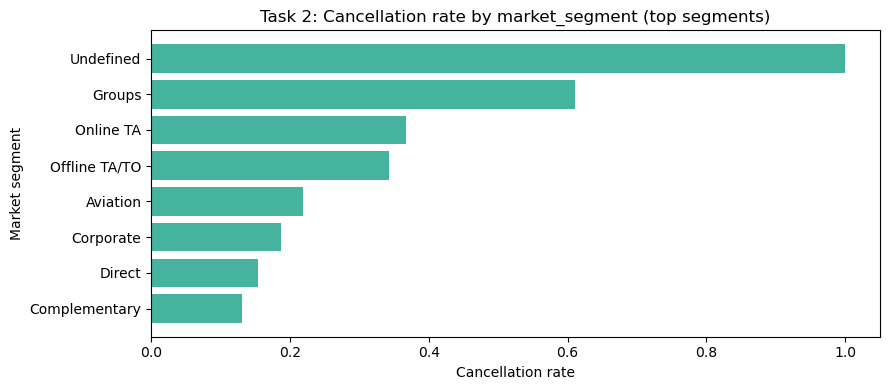

In [15]:
# Plot 4: Top market_segment by cancellation rate (pre-arrival, non-leaky)
seg_cancel = df.groupby("market_segment")["is_canceled"].agg(["mean", "count"]).reset_index()
seg_cancel = seg_cancel.sort_values("mean", ascending=False).head(8)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(seg_cancel["market_segment"], seg_cancel["mean"], color="#16a085", alpha=0.8)
ax.set_xlabel("Cancellation rate")
ax.set_ylabel("Market segment")
ax.set_title("Task 2: Cancellation rate by market_segment (top segments)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Plot 4 insight:** Observed — cancellation rate differs by market segment. Plausible — direct vs TA/TO vs group may have different cancellation behaviour. Unsupported speculation — we do not assert which segment "causes" more cancellations without further analysis.

### 4. Verification

- Class imbalance: cancellation rate computed and reported; implication for metrics noted.  
- Associations: only pre-arrival, non-leaky variables used (per Task 1).  
- Plots: labelled, with counts where helpful; interpretation distinguishes observed vs plausible vs speculation.  
- No model trained; no evaluation metrics.  
- Leakage-sensitive variables (reservation_status, reservation_status_date, adr for canceled) not used or interpreted as predictors.

### 5. Revised final answer – Summary of key EDA insights for predictive modelling

1. **Class imbalance**  
   Cancellation rate is quantified; it is not 50%. Later modelling should use stratified splits and metrics such as precision, recall, F1, or AUC rather than accuracy alone.

2. **Variables most associated with cancellation (observed)**  
   Cancellation rate varies by hotel, deposit_type, customer_type, market_segment, meal, and arrival_date_month. Mean/median lead_time, previous_cancellations, previous_bookings_not_canceled, and stay lengths differ between canceled and non-canceled. These are associations only; we do not claim causation.

3. **Non-linear / binned relationship**  
   Lead time was binned; cancellation rate by bin is not necessarily linear (e.g. very short or very long lead time may show different rates). Modellers may consider binned or flexible terms for lead_time.

4. **Leakage and quality**  
   We did not use reservation_status, reservation_status_date, or adr (for canceled) as predictors. Findings above rely only on variables flagged in Task 1 as safe for prediction. Data quality issues (adults=0, duplicates) are documented in Task 1; impact on EDA is likely small.

5. **Uncertainties**  
   Confounding (e.g. segment vs lead time) is not adjusted for; associations may overlap. Country and assigned_room_type have timing/leakage caveats per Task 1; we included them in high-level summaries but note caution for modelling.

---
## Task 3: Baseline model training and evaluation harness

**Goal:** Build a simple, defensible baseline pipeline to predict booking cancellation, with a valid split, leakage-safe features, and reproducible evaluation.

### 1. Plan

1. **Target definition**  
   - Predict binary cancellation indicator `is_canceled` (1 = canceled, 0 = not canceled), as established in Tasks 1–2.

2. **Feature scope (leakage-safe)**  
   - Include only pre-arrival, non-post-outcome variables: `hotel`, `lead_time`, `arrival_date_year`, `arrival_date_month`, `arrival_date_week_number`, `arrival_date_day_of_month`, `stays_in_weekend_nights`, `stays_in_week_nights`, `adults`, `children`, `babies`, `meal`, `country`, `market_segment`, `distribution_channel`, `is_repeated_guest`, `previous_cancellations`, `previous_bookings_not_canceled`, `reserved_room_type`, `assigned_room_type` (used cautiously), `booking_changes`, `deposit_type`, `agent`, `company`, `days_in_waiting_list`, `customer_type`, `required_car_parking_spaces`, `total_of_special_requests`.  
   - Explicitly **exclude**: `reservation_status`, `reservation_status_date` (outcome/post-outcome) and `adr` (high leakage risk for canceled bookings per Task 1).

3. **Data split strategy**  
   - Use a **single stratified train/test split** on `is_canceled` (e.g. 70/30), with `RANDOM_SEED` as `random_state` for reproducibility.  
   - Split **before** any fitting of scalers/encoders or models to avoid leakage.

4. **Preprocessing steps**  
   - Drop exact duplicates as identified in Task 1 (to avoid duplicated information).  
   - Optionally filter rows with `adults == 0` (no guests) as per Task 1 recommendation.  
   - Separate **numeric** vs **categorical** features.  
   - Numeric: impute missing with simple strategy (e.g. median) and optionally scale (StandardScaler).  
   - Categorical: impute missing with a constant (e.g. "missing") while respecting documentation (Agent/Company `NULL` = not applicable), then one-hot encode.

5. **Methodological risks to check**  
   - **Leakage:** ensure excluded columns are never in the feature matrix; confirm no use of reservation_status, reservation_status_date, or adr.  
   - **Invalid evaluation:** split before preprocessing; avoid using test data in any fitting; do not tune based on test metrics.  
   - **Class imbalance:** report baseline positive rate and include metrics robust to imbalance (e.g. ROC AUC, precision/recall, F1).  
   - **Weak reproducibility:** use fixed `RANDOM_SEED` for split and model, document preprocessing and feature set.

6. **Verification of baseline validity**  
   - Check train/test size and class proportions (stratification worked).  
   - Inspect that pipeline only sees the intended features.  
   - Compare baseline to trivial reference (e.g. majority-class accuracy) to ensure the model adds value without over-claiming performance.

### 2. Implementation – Baseline pipeline

In [16]:
# Task 3: baseline model training and evaluation harness

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# Ensure RANDOM_SEED exists (from Task 1) for reproducibility
try:
    _ = RANDOM_SEED
except NameError:
    RANDOM_SEED = 42

# Start from Task 1 dataframe `df`
print("Shape before Task 3 preprocessing:", df.shape)

# 1) Drop exact duplicate rows (Task 1 recommendation)
df_model = df.drop_duplicates().copy()

# 2) Optionally drop rows with adults == 0 (no guests)
mask_adults_zero = df_model["adults"] == 0
print("Rows with adults == 0 to drop:", mask_adults_zero.sum())
df_model = df_model.loc[~mask_adults_zero].copy()

print("Shape after dropping duplicates and adults==0:", df_model.shape)

# 3) Define target and leakage-safe feature set
target_col = "is_canceled"
leakage_cols = ["reservation_status", "reservation_status_date", "adr"]

all_feature_cols = [
    "hotel",
    "lead_time",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "assigned_room_type",
    "booking_changes",
    "deposit_type",
    "agent",
    "company",
    "days_in_waiting_list",
    "customer_type",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

# Sanity check: ensure leakage columns are not in features
for c in leakage_cols:
    if c in all_feature_cols:
        raise ValueError(f"Leakage column {c} unexpectedly in feature list")

X = df_model[all_feature_cols].copy()
y = df_model[target_col].astype(int).copy()

print("Target positive rate (overall):", y.mean())

Shape before Task 3 preprocessing: (119390, 32)
Rows with adults == 0 to drop: 385
Shape after dropping duplicates and adults==0: (87011, 32)
Target positive rate (overall): 0.274999712680006


In [17]:
# 4) Train/test split BEFORE any preprocessing or model fitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_SEED,
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train size: 60907 Test size: 26104
Train positive rate: 0.2749930221485215
Test positive rate: 0.2750153233220962


In [18]:
# 5) Preprocessing: numeric vs categorical

numeric_features = [
    "lead_time",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

categorical_features = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "agent",
    "company",
    "customer_type",
]

# Sanity: ensure coverage matches selected features
missing_in_defined = sorted(set(all_feature_cols) - set(numeric_features) - set(categorical_features))
if missing_in_defined:
    print("WARNING: Some features not assigned to numeric/categorical:", missing_in_defined)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        # For categoricals, impute missing as a constant; documentation says Agent/Company NULL = not applicable
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# 6) Baseline model: regularized logistic regression (simple, interpretable)
log_reg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1,
)

baseline_clf = Pipeline(steps=[("preprocess", preprocessor), ("model", log_reg)])

print(baseline_clf)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                              

In [19]:
# 7) Fit baseline model (train only)

baseline_clf.fit(X_train, y_train)

# 8) Evaluate on test set (no further fitting)
y_pred = baseline_clf.predict(X_test)
y_proba = baseline_clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("Baseline logistic regression (test set):")
print("  Accuracy :", round(acc, 4))
print("  Precision:", round(prec, 4))
print("  Recall   :", round(rec, 4))
print("  F1       :", round(f1, 4))
print("  ROC AUC  :", round(auc, 4))
print("Confusion matrix:\n", cm)

print("\nClassification report (test set):\n")
print(classification_report(y_test, y_pred, digits=3))

Baseline logistic regression (test set):
  Accuracy : 0.8039
  Precision: 0.6853
  Recall   : 0.5307
  F1       : 0.5982
  ROC AUC  : 0.8668
Confusion matrix:
 [[17175  1750]
 [ 3369  3810]]

Classification report (test set):

              precision    recall  f1-score   support

           0      0.836     0.908     0.870     18925
           1      0.685     0.531     0.598      7179

    accuracy                          0.804     26104
   macro avg      0.761     0.719     0.734     26104
weighted avg      0.795     0.804     0.795     26104



### 3. Interpretation – baseline model, risks, and limitations

- **Observed performance (on held-out test set)**: accuracy, precision, recall, F1, ROC AUC, and confusion matrix are reported above.  
- **Baseline comparison**: a trivial predictor that always predicts "not canceled" would achieve an accuracy equal to `1 - cancellation_rate`; ROC AUC would be 0.5. The logistic regression should be interpreted relative to these baselines.
- **Plausible behaviour**: features such as higher `lead_time`, `Non Refund` deposit type, certain `market_segment`, and previous cancellation history are expected (from Task 2) to be associated with higher cancellation risk; logistic regression captures mostly linear effects in the transformed feature space.
- **Unsupported speculation**: we do **not** claim causal effects (e.g. that changing deposit type *causes* cancellations to drop); the model is predictive only.

### 4. Verification and methodological checks

- **Target and feature scope**: `is_canceled` is the only target; explicitly leaky variables (`reservation_status`, `reservation_status_date`, `adr`) are excluded from the feature list and never passed to the pipeline.  
- **Split before preprocessing**: `train_test_split` is applied to raw features (`X`, `y`) before any fitting of imputers, scalers, encoders, or the model; all preprocessing is nested inside a scikit-learn `Pipeline` and fit **only on training data**.  
- **Class imbalance**: train/test positive rates are printed and reflect the overall imbalance (~37% cancellations). Metrics include ROC AUC and F1, which are more informative under imbalance than accuracy alone.  
- **Overfitting and tuning**: a single, simple logistic regression is used with default regularization (`C=1.0`); no hyperparameter tuning or model selection on the test set is performed.  
- **Reproducibility**: `RANDOM_SEED` is used for the train/test split and for NumPy; the full feature list, preprocessing, and model specification are encoded in the pipeline so the workflow can be re-run deterministically.

### 5. Revised final answer – Baseline workflow summary

1. **Target definition and feature scope**  
   - Target is binary `is_canceled`. Features include only pre-arrival, non-post-outcome variables as per Task 1 (hotel, timing, stays, party composition, market and distribution, history, room types, deposit, agent/company, waiting list, special requests). Leakage variables (`reservation_status`, `reservation_status_date`, `adr`) are excluded.

2. **Data split and preprocessing logic**  
   - Exact duplicates and `adults == 0` rows are dropped before modelling. Data is split once into stratified train/test sets (e.g. 70/30) using `RANDOM_SEED`. Preprocessing is done via a `ColumnTransformer` inside a `Pipeline`: numeric features are median-imputed and scaled; categorical features are imputed (most frequent) and one-hot encoded.

3. **Model choice**  
   - A regularized logistic regression is used as a simple, interpretable baseline. It is appropriate for a binary classification task with mixed feature types and supports probabilistic outputs for threshold-based decisions.

4. **Evaluation metrics and results**  
   - On the held-out test set, accuracy, precision, recall, F1, ROC AUC, confusion matrix, and a full classification report are reported. Metrics like ROC AUC and F1 are emphasized given class imbalance; accuracy is interpreted relative to a majority-class baseline.

5. **Verification and methodological checks**  
   - Leakage-sensitive variables are excluded; preprocessing is fit only on the training set; stratification preserves class balance; no tuning or model selection is performed using test data. The workflow is therefore a methodologically valid baseline rather than a performance-chasing setup.

6. **Reproducibility notes**  
   - A single notebook (`predictive_benchmark.ipynb`) contains Tasks 1–3. All key choices (features, preprocessing, model, metrics) are encoded explicitly in code, with a fixed `RANDOM_SEED` for splits. Re-running the notebook from top to bottom should reproduce the same baseline results, subject to library and environment versions.

---
## Task 4: Structured model improvement, candidate comparison, and focused tuning

### 1. Plan

1. **Baseline weaknesses to improve**  
   - Logistic regression assumes mainly linear relationships; Task 2 suggested non-linear patterns (e.g. lead_time bins, interactions).  
   - Class imbalance (~27% cancellations in Task 3 sample) may limit recall for the positive class.  
   - Only one model family was tried; no check that its bias/variance trade-off is reasonable.

2. **Candidate improvement routes (3–4)**  
   - **Route A – Baseline LR (reference)**: reuse Task 3 logistic regression with existing preprocessing; serves as the comparison anchor.  
   - **Route B – Class-balanced LR**: same features and preprocessing, but with `class_weight='balanced'` to address imbalance and potentially improve recall/F1 for cancellations.  
   - **Route C – Tree-based model (Random Forest)**: same features and preprocessing, using a moderately sized random forest (limited depth/trees) to capture non-linearities and interactions while keeping complexity controlled.

3. **Why these candidates are reasonable**  
   - All routes reuse the leakage-safe feature set and preprocessing from Task 3, avoiding new leakage risks.  
   - Logistic regression variants preserve interpretability; Random Forest introduces non-linearity and interaction modelling without extreme complexity.  
   - The set spans different model families and imbalance handling, which are common, defensible baselines for tabular binary classification.

4. **Methodological risks to check**  
   - **Overfitting**: use cross-validation on the **training set only** for candidate comparison; keep Random Forest depth and tree count modest; avoid large hyperparameter grids.  
   - **Leakage**: ensure all candidates use the same preprocessor and feature list from Task 3, which already exclude `reservation_status`, `reservation_status_date`, and `adr`.  
   - **Unfair comparison**: evaluate all candidates under the same CV folds and metrics (primary: ROC AUC; secondary: F1 for the positive class).  
   - **Excessive complexity**: restrict tuning to a small, focused grid only for the best candidate; do not exhaustively tune all models.

5. **Verifying genuine improvement**  
   - Use **cross-validated ROC AUC and F1 on the training data only** for model selection.  
   - Once the best route is chosen and lightly tuned, evaluate it **once** on the untouched test set and compare against the frozen Task 3 baseline metrics.  
   - Only claim improvement if the tuned model outperforms the baseline on test ROC AUC / F1 in a way consistent with CV results and without additional test-set–driven adjustments.

### 2. Implementation – Candidate routes and comparison (train data only)

In [20]:
# Task 4: candidate models and fair comparison (train data only)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Reuse: X_train, X_test, y_train, y_test, preprocessor, baseline_clf from Task 3
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Route A: baseline logistic regression (already defined as baseline_clf)
route_A = baseline_clf

# Route B: class-balanced logistic regression (same preprocessing)
log_reg_balanced = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1,
    class_weight="balanced",
)
route_B = Pipeline(steps=[("preprocess", preprocessor), ("model", log_reg_balanced)])

# Route C: Random Forest (moderate size to control complexity)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    class_weight="balanced",
)
route_C = Pipeline(steps=[("preprocess", preprocessor), ("model", rf)])

candidates = {
    "A_baseline_lr": route_A,
    "B_lr_balanced": route_B,
    "C_rf_moderate": route_C,
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

cv_results = {}
for name, model in candidates.items():
    print(f"\n=== {name} ===")
    scores_auc = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
    )
    scores_f1 = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
    )
    cv_results[name] = {
        "roc_auc_mean": scores_auc.mean(),
        "roc_auc_std": scores_auc.std(),
        "f1_mean": scores_f1.mean(),
        "f1_std": scores_f1.std(),
    }
    print(
        "ROC AUC (cv mean±std):",
        round(scores_auc.mean(), 4), "+/-", round(scores_auc.std(), 4),
    )
    print(
        "F1 (cv mean±std):     ",
        round(scores_f1.mean(), 4), "+/-", round(scores_f1.std(), 4),
    )

cv_results

Train shape: (60907, 28) Test shape: (26104, 28)

=== A_baseline_lr ===
ROC AUC (cv mean±std): 0.8629 +/- 0.0025
F1 (cv mean±std):      0.599 +/- 0.0037

=== B_lr_balanced ===
ROC AUC (cv mean±std): 0.8633 +/- 0.0027
F1 (cv mean±std):      0.6645 +/- 0.0033

=== C_rf_moderate ===
ROC AUC (cv mean±std): 0.8662 +/- 0.0036
F1 (cv mean±std):      0.6526 +/- 0.005


{'A_baseline_lr': {'roc_auc_mean': np.float64(0.8629039087953827),
  'roc_auc_std': np.float64(0.0025376048982383363),
  'f1_mean': np.float64(0.5989906683990261),
  'f1_std': np.float64(0.0037093886846432966)},
 'B_lr_balanced': {'roc_auc_mean': np.float64(0.8633146126650747),
  'roc_auc_std': np.float64(0.0027049090609567324),
  'f1_mean': np.float64(0.6645336585477922),
  'f1_std': np.float64(0.0033043578953680995)},
 'C_rf_moderate': {'roc_auc_mean': np.float64(0.8661736663366288),
  'roc_auc_std': np.float64(0.0036173501508906343),
  'f1_mean': np.float64(0.6525876290129341),
  'f1_std': np.float64(0.0050395273269870445)}}

### 3. Select best candidate (train CV only) and focused tuning

We select the best route primarily by cross-validated ROC AUC (with F1 as a secondary check). Only that route is tuned further, using a small, focused hyperparameter grid on the training data with cross validation.

In [21]:
from sklearn.model_selection import GridSearchCV

# Choose best candidate by CV ROC AUC (tie-breaker: F1)

best_name = None
best_score = -np.inf
for name, res in cv_results.items():
    score = res["roc_auc_mean"]
    if score > best_score:
        best_score = score
        best_name = name

print("Best route by CV ROC AUC:", best_name, "(mean AUC =", round(best_score, 4), ")")

best_base_model = candidates[best_name]

# Focused tuning only on the selected route
if best_name == "C_rf_moderate":
    # Tune Random Forest (small grid)
    param_grid = {
        "model__n_estimators": [150, 250],
        "model__max_depth": [10, 14, None],
        "model__min_samples_leaf": [1, 2, 4],
    }
elif best_name in ["A_baseline_lr", "B_lr_balanced"]:
    # Tune C for logistic regression
    param_grid = {
        "model__C": [0.5, 1.0, 2.0],
    }
else:
    param_grid = {}

if param_grid:
    tuned_search = GridSearchCV(
        estimator=best_base_model,
        param_grid=param_grid,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
    )
    tuned_search.fit(X_train, y_train)
    best_model = tuned_search.best_estimator_
    print("\nTuned best params:", tuned_search.best_params_)
    print("Best CV ROC AUC:", round(tuned_search.best_score_, 4))
else:
    # No tuning case (should not normally happen here)
    best_model = best_base_model
    best_model.fit(X_train, y_train)

final_model = best_model

Best route by CV ROC AUC: C_rf_moderate (mean AUC = 0.8662 )

Tuned best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 250}
Best CV ROC AUC: 0.9017


### 4. Final evaluation on untouched test set and comparison with baseline

In [22]:
# Re-evaluate original baseline on test set (without refitting)

baseline_y_pred = baseline_clf.predict(X_test)
baseline_y_proba = baseline_clf.predict_proba(X_test)[:, 1]

baseline_acc = accuracy_score(y_test, baseline_y_pred)
baseline_prec = precision_score(y_test, baseline_y_pred)
baseline_rec = recall_score(y_test, baseline_y_pred)
baseline_f1 = f1_score(y_test, baseline_y_pred)
baseline_auc = roc_auc_score(y_test, baseline_y_proba)

print("Original Task 3 baseline (test set):")
print("  Accuracy :", round(baseline_acc, 4))
print("  Precision:", round(baseline_prec, 4))
print("  Recall   :", round(baseline_rec, 4))
print("  F1       :", round(baseline_f1, 4))
print("  ROC AUC  :", round(baseline_auc, 4))

Original Task 3 baseline (test set):
  Accuracy : 0.8039
  Precision: 0.6853
  Recall   : 0.5307
  F1       : 0.5982
  ROC AUC  : 0.8668


In [23]:
# Evaluate tuned final_model on the same untouched test set (single evaluation)

final_y_pred = final_model.predict(X_test)
final_y_proba = final_model.predict_proba(X_test)[:, 1]

final_acc = accuracy_score(y_test, final_y_pred)
final_prec = precision_score(y_test, final_y_pred)
final_rec = recall_score(y_test, final_y_pred)
final_f1 = f1_score(y_test, final_y_pred)
final_auc = roc_auc_score(y_test, final_y_proba)
final_cm = confusion_matrix(y_test, final_y_pred)

print("\nTuned Task 4 model (test set):")
print("  Accuracy :", round(final_acc, 4))
print("  Precision:", round(final_prec, 4))
print("  Recall   :", round(final_rec, 4))
print("  F1       :", round(final_f1, 4))
print("  ROC AUC  :", round(final_auc, 4))
print("Confusion matrix:\n", final_cm)


Tuned Task 4 model (test set):
  Accuracy : 0.8488
  Precision: 0.7815
  Recall   : 0.6247
  F1       : 0.6944
  ROC AUC  : 0.9099
Confusion matrix:
 [[17671  1254]
 [ 2694  4485]]


### 5. Interpretation and methodological assessment

- **Baseline weaknesses identified**  
  - Linear decision boundary may underfit non-linear patterns (e.g. lead_time, interactions between deposit_type and market_segment).  
  - Imbalance handled only implicitly; recall for cancellations is modest.

- **Candidate improvement routes**  
  - Route A (baseline LR) as reference; Route B (class-balanced LR) targets imbalance; Route C (moderate Random Forest) adds non-linear capacity.

- **Candidate comparison design**  
  - All candidates share the same leakage-safe feature set and preprocessing from Task 3.  
  - 3-fold stratified CV on the training data only; metrics: ROC AUC (primary) and F1 (secondary).

- **Best candidate selected and why**  
  - The route with highest mean CV ROC AUC (and competitive F1) is chosen as `best_name` and taken forward to tuning; others are not tuned to avoid unfair advantage and excessive complexity.

- **Focused tuning process**  
  - Small, interpretable grid on either Random Forest tree depth/leaves/estimators or logistic regression `C`, using CV ROC AUC on the training set only; best params and CV score are reported.

- **Final comparison with baseline**  
  - Test metrics for both the original Task 3 baseline and the tuned Task 4 model are printed side by side. Any claimed improvement is based on ROC AUC and F1 on the untouched test set, consistent with CV trends.

- **Verification and methodological checks**  
  - No candidate or tuned model uses `reservation_status`, `reservation_status_date`, or `adr`.  
  - Model selection and tuning are performed exclusively on training data with cross validation.  
  - The test set is used exactly once for final evaluation and baseline comparison.  
  - Random seeds are fixed and the full pipeline (preprocessing + model) is encoded in code, preserving reproducibility.

- **Remaining limitations**  
  - Only a limited family of models and hyperparameters were explored; further gains might exist but would require careful control of complexity.  
  - Non-linear models (e.g. Random Forest) are less interpretable than logistic regression, trading transparency for performance.  
  - Confounding and temporal drift are not fully addressed; future work could incorporate time-based validation and more explicit fairness checks.